In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("placement_linear.csv")

In [ ]:
df.head()

,cgpa,iq,placement
0,6.88,95,0
1,8.24,126,1
2,5.00,127,0
3,6.36,146,1
4,5.66,111,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       120 non-null    float64
 1   iq         120 non-null    int64  
 2   placement  120 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.9 KB


In [ ]:
df.shape

(120, 3)

In [ ]:
df.head()

,cgpa,iq,placement
0,6.88,95,0
1,8.24,126,1
2,5.00,127,0
3,6.36,146,1
4,5.66,111,0


In [ ]:
import matplotlib.pyplot as plt

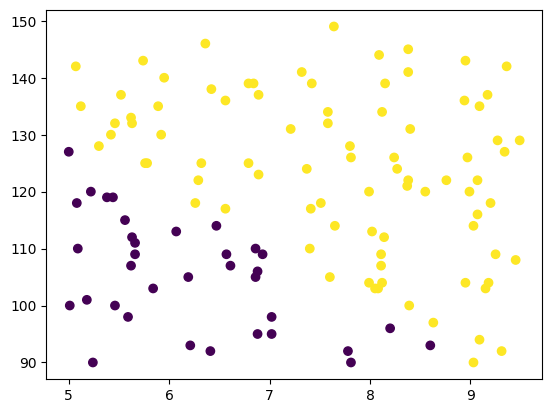

In [ ]:
plt.scatter(df["cgpa"],df["iq"], c=df["placement"])

In [ ]:
x = df.drop("placement",axis=1)
y = df['placement']

In [ ]:
x

,cgpa,iq
0,6.88,95
1,8.24,126
2,5.00,127
3,6.36,146
4,5.66,111
...,...,...
115,8.40,131
116,8.39,100
117,9.15,103
118,8.20,96


In [ ]:
y

,placement
0,0
1,1
2,0
3,1
4,0
...,...
115,1
116,1
117,1
118,0


In [ ]:
x.shape

(120, 2)

In [ ]:
y.shape

(120,)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [ ]:
x_train

,cgpa,iq
22,6.41,92
36,8.09,144
71,5.62,133
103,6.61,107
55,5.24,90
...,...,...
98,5.01,100
26,5.38,119
23,8.12,104
69,7.64,149


In [ ]:
y_train

,placement
22,0
36,1
71,1
103,0
55,0
...,...
98,0
26,0
23,1
69,1


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
std = StandardScaler()


In [ ]:
x_train = std.fit_transform(x_train)


In [ ]:
x_train

array([[-0.67307203, -1.70636738],
       [ 0.58891194,  1.61528226],
       [-1.26650496,  0.91262561],
       [-0.52283584, -0.74819922],
       [-1.55195372, -1.83412314],
       [ 1.42272277, -0.04554256],
       [ 0.0705971 , -0.55656558],
       [ 0.20580966,  0.97650348],
       [-1.59702457, -1.13146648],
       [ 1.29502202, -0.30105407],
       [ 1.40018735,  1.16813712],
       [ 0.80675441,  0.20996895],
       [-1.26650496, -0.74819922],
       [-1.67965447,  1.48752651],
       [ 1.61051801, -0.68432134],
       [ 0.67154184, -1.45085587],
       [-1.25899315,  0.84874773],
       [ 1.47530544,  0.65711409],
       [ 1.22741573,  1.10425924],
       [ 1.23492754,  1.55140438],
       [ 0.72412451,  0.33772471],
       [ 1.09220316,  0.20996895],
       [ 0.08562072,  1.29589287],
       [ 0.25839233, -0.30105407],
       [ 0.60393556, -0.74819922],
       [ 0.58140013, -1.00371073],
       [ 1.50535268, -1.70636738],
       [ 0.07810891, -0.10942044],
       [ 0.62647099,

In [ ]:
import warnings
warnings.filterwarnings("ignore")
x_test = std.transform(x_test)

In [ ]:
x_test

array([[-0.38762327,  1.29589287],
       [ 1.32506925,  0.20996895],
       [-1.41674115,  0.72099197],
       [-0.32001699, -0.81207709],
       [-1.16133963,  0.40160258],
       [-1.23645772, -0.49268771],
       [-1.23645772, -0.62044346],
       [-1.73223714,  0.52935834],
       [-0.82330821, -1.64248951],
       [-0.62800117, -0.30105407],
       [ 1.34009287, -1.57861163],
       [ 1.64056524,  0.65711409]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accurancy = accuracy_score(y_test,y_pred)

In [ ]:
accurancy

0.9166666666666666

In [ ]:
y_test

,placement
8,1
96,1
5,1
16,0
28,1
4,0
57,0
2,0
84,0
100,0


In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

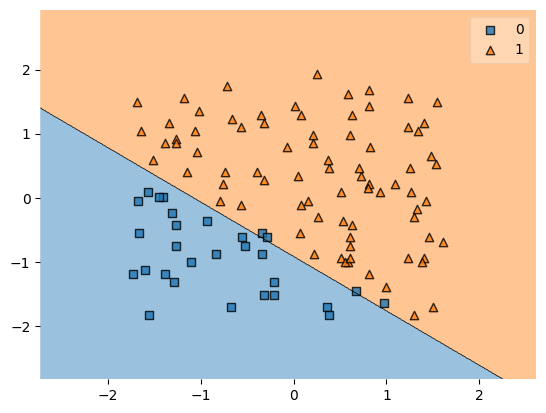

In [ ]:
plot_decision_regions(x_train,y_train.values,clf=lr)

In [ ]:
import pickle

In [ ]:
pickle.dump(lr,open("placement_lr.pkl","wb"))